In [ ]:
# Mass Fractions / Convergence Response Analysis

This notebook analyzes the **convergence response fraction** $F$ for Replace models at both statistical and pixel level:

$$F = \frac{\kappa_{\rm Replace} - \kappa_{\rm DMO}}{\kappa_{\rm Hydro} - \kappa_{\rm DMO}}$$

This metric quantifies **how much of the baryonic effect on convergence is captured** by replacing halos in specific mass and radius ranges.

## Key Questions:
1. **How does F vary with mass threshold and replacement radius?**
2. **What is the pixel-level distribution of F?**  
3. **How does F evolve with source redshift?**
4. **Which mass/radius bins contribute most to the total baryonic signal?**

## Analysis Approaches:
1. **C_ℓ-based**: Compute F from angular power spectrum ratios (Sections 3-4)
2. **Raw κ maps**: Compute F directly from convergence map pixels (Section 5)
   - Mean convergence: $F_{\langle\kappa\rangle}$
   - Variance: $F_{\sigma^2}$
   - Pixel-by-pixel distribution

## Data:
- **Convergence maps**: 1024×1024 pixels, 5° FOV, 2000 realizations per model
- **Source redshifts**: 40 planes from $z_s = 0.03$ to $z_s = 2.57$
- **Models**: 100+ Replace configurations spanning mass $10^{12} - 10^{15} M_\odot/h$ and radius $0-5 R_{200}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Style
try:
    import scienceplots
    plt.style.use(['science', 'notebook'])
except ImportError:
    plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

# Paths
STATS_BASE = Path('/mnt/home/mlee1/ceph/hydro_replace_stats')

# Constants from the pipeline
KAPPA_REDSHIFTS = {
    1: 0.034, 2: 0.070, 3: 0.105, 4: 0.142, 5: 0.179,
    6: 0.216, 7: 0.255, 8: 0.294, 9: 0.335, 10: 0.376,
    11: 0.418, 12: 0.462, 13: 0.506, 14: 0.552, 15: 0.599,
    16: 0.648, 17: 0.698, 18: 0.749, 19: 0.803, 20: 0.858,
    21: 0.914, 22: 0.973, 23: 1.034, 24: 1.097, 25: 1.163,
    26: 1.231, 27: 1.302, 28: 1.375, 29: 1.452, 30: 1.532,
    31: 1.615, 32: 1.703, 33: 1.794, 34: 1.889, 35: 1.989,
    36: 2.094, 37: 2.203, 38: 2.319, 39: 2.440, 40: 2.568
}
KAPPA_Z_ARRAY = np.array([KAPPA_REDSHIFTS[i] for i in range(1, 41)])

# Snapshot redshifts (for lensplanes/mass)
SNAPSHOT_REDSHIFTS = np.array([0.04, 0.15, 0.27, 0.40, 0.50, 0.64, 0.78, 0.93, 1.07, 1.18,
                               1.36, 1.50, 1.65, 1.82, 1.93, 2.12, 2.32, 2.49, 2.68, 2.87])

print("Configuration loaded")
print(f"Stats base: {STATS_BASE}")
print(f"N_kappa planes: {len(KAPPA_REDSHIFTS)}")
print(f"Source z range: {KAPPA_Z_ARRAY.min():.2f} - {KAPPA_Z_ARRAY.max():.2f}")

Configuration loaded
Stats base: /mnt/home/mlee1/ceph/hydro_replace_stats
N_kappa planes: 40
Source z range: 0.03 - 2.57


## 1. Define Model Grid and Data Loaders

We have 100+ Replace models spanning:
- **Mass bounds**: $10^{12} - 10^{15}$ M$_\odot$/h (discrete bins and cumulative thresholds)
- **Radius bounds**: 0 - 5 $R_{200}$ (discrete shells and cumulative radii)

In [2]:
def build_model_name(Ml, Mu, Ri, Ro):
    """Build model name from mass and radius bounds."""
    Ml_str = f"{Ml:.2e}".replace('e+', 'e')
    Mu_str = f"{Mu:.2e}".replace('e+', 'e')
    return f"hydro_replace_Ml_{Ml_str}_Mu_{Mu_str}_Ri_{Ri:.1f}_Ro_{Ro:.1f}"


def load_stats(model, keys=None):
    """Load statistics from stats.h5 file."""
    path = STATS_BASE / model / 'stats.h5'
    if not path.exists():
        return None
    
    try:
        with h5py.File(path, 'r') as f:
            if keys is None:
                keys = list(f.keys())
            data = {key: f[key][()] for key in keys if key in f}
        return data if data else None
    except Exception as e:
        print(f"Error loading {model}: {e}")
        return None


# Define model configurations
MASS_EDGES = [1.00e12, 3.16e12, 1.00e13, 3.16e13, 1.00e15]
RADIUS_EDGES = [0.0, 0.5, 1.0, 3.0, 5.0]

# Mass labels for plots
MASS_LABELS = {
    1.00e12: r'$10^{12}$',
    3.16e12: r'$10^{12.5}$',
    1.00e13: r'$10^{13}$',
    3.16e13: r'$10^{13.5}$',
    1.00e15: r'$10^{15}$'
}

# Generate all discrete models (bin × shell combinations)
DISCRETE_MODELS = {}
for i in range(len(MASS_EDGES) - 1):
    for j in range(len(RADIUS_EDGES) - 1):
        Ml, Mu = MASS_EDGES[i], MASS_EDGES[i+1]
        Ri, Ro = RADIUS_EDGES[j], RADIUS_EDGES[j+1]
        model_name = build_model_name(Ml, Mu, Ri, Ro)
        DISCRETE_MODELS[model_name] = {'Ml': Ml, 'Mu': Mu, 'Ri': Ri, 'Ro': Ro}

# Generate cumulative models (M > threshold, r < outer)
CUMULATIVE_MODELS = {}
for Ml in MASS_EDGES[:-1]:  # Exclude 1e15 as lower bound
    for Ro in RADIUS_EDGES[1:]:  # Exclude 0.0 as outer
        model_name = build_model_name(Ml, 1.00e15, 0.0, Ro)
        CUMULATIVE_MODELS[model_name] = {'Ml': Ml, 'Mu': 1.00e15, 'Ri': 0.0, 'Ro': Ro}

print(f"Discrete models (mass bin × radius shell): {len(DISCRETE_MODELS)}")
print(f"Cumulative models (M > threshold, r < outer): {len(CUMULATIVE_MODELS)}")
print(f"\nExample discrete: {list(DISCRETE_MODELS.keys())[0]}")
print(f"Example cumulative: {list(CUMULATIVE_MODELS.keys())[0]}")

Discrete models (mass bin × radius shell): 16
Cumulative models (M > threshold, r < outer): 16

Example discrete: hydro_replace_Ml_1.00e12_Mu_3.16e12_Ri_0.0_Ro_0.5
Example cumulative: hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_0.5


## 2. Load Base Models (DMO and Hydro)

These serve as the reference for computing the response fraction F.

In [3]:
# Load base models
print("Loading DMO and Hydro statistics...")
stats_dmo = load_stats('dmo')
stats_hydro = load_stats('hydro')

if stats_dmo is None or stats_hydro is None:
    raise FileNotFoundError("Could not load DMO or Hydro stats!")

print("\n=== Dataset shapes ===")
for key in stats_dmo.keys():
    print(f"  {key}: {stats_dmo[key].shape}")

# Store in dict for easy access
BASE_STATS = {
    'dmo': stats_dmo,
    'hydro': stats_hydro
}

Loading DMO and Hydro statistics...

=== Dataset shapes ===
  Cl: (2000, 40, 724)
  Pk: (20, 40, 2896)
  S0: (2000, 40, 3)
  S1: (2000, 40, 5, 3)
  V0: (2000, 40, 51)
  V1: (2000, 40, 51)
  V2: (2000, 40, 51)
  ell_bins: (724,)
  k_bins: (2896,)
  mass: (20, 40)
  mf_thresholds: (51,)
  minima: (2000, 40, 50)
  pdf: (2000, 40, 50)
  peaks: (2000, 40, 50)
  sn_bin_edges: (51,)
  wst_moments: (3,)
  wst_scales: (5,)


## 3. Examine the Baryonic Signal in Convergence

Before computing F for Replace models, let's understand the baryonic effect:
- How much does Hydro differ from DMO?
- At which source redshifts is the signal strongest?

Cl shape: (2000, 40, 724)
ell range: 546 - 327565


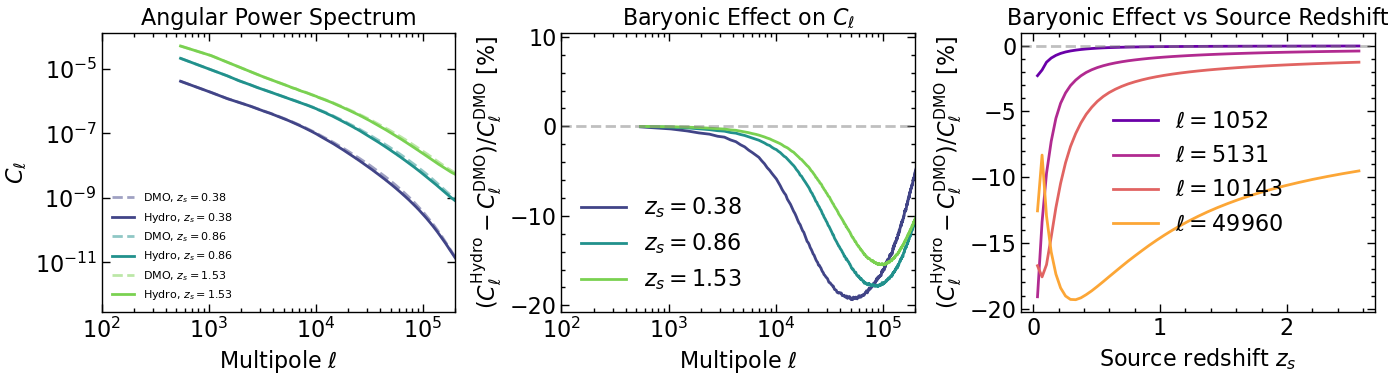


=== Baryonic Effect Summary ===
z_s = 0.38: Max suppression = -19.4% at ℓ = 52241
z_s = 0.86: Max suppression = -17.9% at ℓ = 84812
z_s = 1.53: Max suppression = -15.5% at ℓ = 100188


In [ ]:
# Analyze the C_ℓ power spectrum response
# Shape: (N_realizations=2000, N_kappa=40, N_ell)

Cl_dmo = stats_dmo['Cl']
Cl_hydro = stats_hydro['Cl']
ell_bins = stats_dmo['ell_bins']

print(f"Cl shape: {Cl_dmo.shape}")
print(f"ell range: {ell_bins.min():.0f} - {ell_bins.max():.0f}")

# Mean across realizations
Cl_dmo_mean = np.mean(Cl_dmo, axis=0)  # (40, N_ell)
Cl_hydro_mean = np.mean(Cl_hydro, axis=0)

# Fractional difference: (Hydro - DMO) / DMO
frac_diff = (Cl_hydro_mean - Cl_dmo_mean) / Cl_dmo_mean

# Plot for select source redshifts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Select a few representative source redshifts
z_indices = [9, 19, 29]  # z ≈ 0.38, 0.80, 1.45
z_labels = [f'$z_s = {KAPPA_Z_ARRAY[i]:.2f}$' for i in z_indices]

# Left: C_ℓ comparison
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(z_indices)))
for idx, z_idx in enumerate(z_indices):
    ax.loglog(ell_bins, Cl_dmo_mean[z_idx], '--', color=colors[idx], alpha=0.5, label=f'DMO, {z_labels[idx]}')
    ax.loglog(ell_bins, Cl_hydro_mean[z_idx], '-', color=colors[idx], label=f'Hydro, {z_labels[idx]}')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$C_\ell$')
ax.set_title('Angular Power Spectrum')
ax.legend(fontsize=8)
ax.set_xlim(100, 2e5)

# Middle: Fractional difference
ax = axes[1]
for idx, z_idx in enumerate(z_indices):
    ax.semilogx(ell_bins, frac_diff[z_idx] * 100, color=colors[idx], label=z_labels[idx])
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$(C_\ell^{\rm Hydro} - C_\ell^{\rm DMO}) / C_\ell^{\rm DMO}$ [%]')
ax.set_title('Baryonic Effect on $C_\ell$')
ax.legend()
ax.set_xlim(100, 2e5)

# Right: Fractional difference vs source redshift at fixed ℓ
ax = axes[2]
ell_targets = [1000, 5000, 10000, 50000]
colors_ell = plt.cm.plasma(np.linspace(0.2, 0.8, len(ell_targets)))
for idx, ell_target in enumerate(ell_targets):
    ell_idx = np.argmin(np.abs(ell_bins - ell_target))
    actual_ell = ell_bins[ell_idx]
    ax.plot(KAPPA_Z_ARRAY, frac_diff[:, ell_idx] * 100, 
            color=colors_ell[idx], label=rf'$\ell = {actual_ell:.0f}$')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel(r'Source redshift $z_s$')
ax.set_ylabel(r'$(C_\ell^{\rm Hydro} - C_\ell^{\rm DMO}) / C_\ell^{\rm DMO}$ [%]')
ax.set_title('Baryonic Effect vs Source Redshift')
ax.legend()

plt.tight_layout()
plt.savefig('figures/baryonic_effect_Cl.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n=== Baryonic Effect Summary ===")
for z_idx in z_indices:
    peak_effect = np.min(frac_diff[z_idx]) * 100  # Most negative = strongest suppression
    ell_peak = ell_bins[np.argmin(frac_diff[z_idx])]
    print(f"z_s = {KAPPA_Z_ARRAY[z_idx]:.2f}: Max suppression = {peak_effect:.1f}% at ℓ = {ell_peak:.0f}")

## 4. Compute Response Fraction F for C_ℓ

Now we load Replace models and compute:
$$F(\ell, z_s) = \frac{C_\ell^{\rm Replace} - C_\ell^{\rm DMO}}{C_\ell^{\rm Hydro} - C_\ell^{\rm DMO}}$$

We'll also compute **integrated metrics** to get a single F value per model.

In [5]:
def compute_F_Cl(Cl_replace, Cl_dmo, Cl_hydro, threshold=0.01):
    """
    Compute response fraction F = (R - D) / (H - D) for C_ℓ.
    
    Parameters
    ----------
    Cl_replace : ndarray, shape (N_real, N_kappa, N_ell)
    Cl_dmo : ndarray, same shape
    Cl_hydro : ndarray, same shape
    threshold : float
        Mask bins where |H - D| / D < threshold
        
    Returns
    -------
    F_mean : ndarray, shape (N_kappa, N_ell)
        Mean F across realizations
    F_err : ndarray, same shape
        Standard error on F
    mask : ndarray, same shape (bool)
        True where F is reliable
    """
    # Mean across realizations first (more stable)
    R_mean = np.mean(Cl_replace, axis=0)
    D_mean = np.mean(Cl_dmo, axis=0)
    H_mean = np.mean(Cl_hydro, axis=0)
    
    # Standard errors
    R_err = np.std(Cl_replace, axis=0) / np.sqrt(Cl_replace.shape[0])
    D_err = np.std(Cl_dmo, axis=0) / np.sqrt(Cl_dmo.shape[0])
    H_err = np.std(Cl_hydro, axis=0) / np.sqrt(Cl_hydro.shape[0])
    
    # Compute F
    numerator = R_mean - D_mean
    denominator = H_mean - D_mean
    
    with np.errstate(divide='ignore', invalid='ignore'):
        F_mean = numerator / denominator
        
        # Error propagation
        num_err = np.sqrt(R_err**2 + D_err**2)
        den_err = np.sqrt(H_err**2 + D_err**2)
        F_err = np.abs(F_mean) * np.sqrt((num_err/numerator)**2 + (den_err/denominator)**2)
    
    # Mask where baryonic effect is small
    frac_effect = np.abs(denominator) / np.abs(D_mean)
    mask = frac_effect > threshold
    
    # Apply mask
    F_mean = np.where(mask, F_mean, np.nan)
    F_err = np.where(mask, F_err, np.nan)
    
    return F_mean, F_err, mask


def compute_integrated_F(F_mean, F_err, weights=None, axis=-1):
    """
    Compute weighted average F over bins.
    
    Parameters
    ----------
    F_mean : ndarray
    F_err : ndarray
    weights : ndarray, optional
        Bin weights. If None, uses inverse-variance weighting.
    axis : int
        Axis to integrate over
        
    Returns
    -------
    F_integrated : float or ndarray
    F_integrated_err : float or ndarray
    """
    if weights is None:
        # Inverse-variance weighting
        with np.errstate(divide='ignore', invalid='ignore'):
            w = np.where((F_err > 0) & np.isfinite(F_err) & np.isfinite(F_mean),
                        1.0 / F_err**2, 0.0)
    else:
        w = np.where(np.isfinite(F_mean), weights, 0.0)
    
    weighted_sum = np.nansum(w * F_mean, axis=axis)
    sum_w = np.nansum(w, axis=axis)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        F_int = np.where(sum_w > 0, weighted_sum / sum_w, np.nan)
        F_int_err = np.where(sum_w > 0, 1.0 / np.sqrt(sum_w), np.nan)
    
    return F_int, F_int_err


# Load a few representative cumulative models to test
test_models = [
    'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_0.5',
    'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_1.0',
    'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_3.0',
    'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0',
]

print("Loading test models...")
test_stats = {}
for model in test_models:
    stats = load_stats(model, keys=['Cl'])
    if stats is not None:
        test_stats[model] = stats
        print(f"  Loaded: {model}")
    else:
        print(f"  MISSING: {model}")

print(f"\nLoaded {len(test_stats)} / {len(test_models)} test models")

Loading test models...
  Loaded: hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_0.5
  Loaded: hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_1.0
  Loaded: hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_3.0
  Loaded: hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0

Loaded 4 / 4 test models


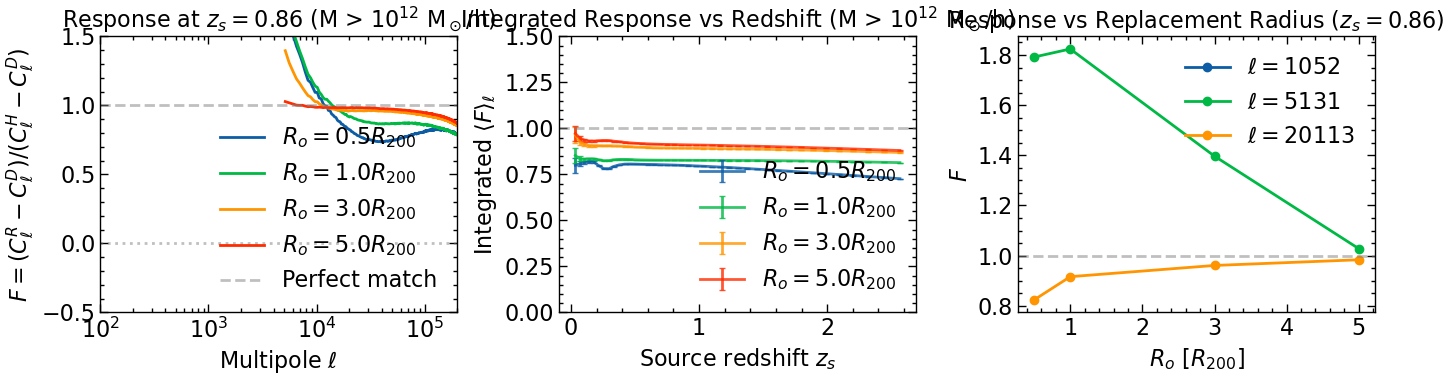

In [ ]:
# Compute F for test models
import re
test_F_results = {}

for model, stats in test_stats.items():
    F_mean, F_err, mask = compute_F_Cl(stats['Cl'], Cl_dmo, Cl_hydro)
    
    # Integrated F across ℓ for each source redshift
    F_int, F_int_err = compute_integrated_F(F_mean, F_err, axis=-1)
    
    test_F_results[model] = {
        'F_mean': F_mean,  # (40, N_ell)
        'F_err': F_err,
        'mask': mask,
        'F_integrated_z': F_int,  # (40,) - one per source redshift
        'F_integrated_z_err': F_int_err
    }

# Plot F(ℓ) for different radii at fixed z_s
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

z_idx = 19  # z_s ≈ 0.80
radius_colors = {0.5: 'C0', 1.0: 'C1', 3.0: 'C2', 5.0: 'C3'}

# Left: F(ℓ) for different radii
ax = axes[0]
for model, results in test_F_results.items():
    Ro = CUMULATIVE_MODELS.get(model, {}).get('Ro', 0)
    if Ro == 0:
        # Parse from model name
        import re
        match = re.search(r'Ro_(\d+\.?\d*)', model)
        Ro = float(match.group(1)) if match else 0
    
    color = radius_colors.get(Ro, 'gray')
    valid = results['mask'][z_idx]
    ax.semilogx(ell_bins[valid], results['F_mean'][z_idx, valid], 
                color=color, label=rf'$R_o = {Ro} R_{{200}}$')
    
ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='Perfect match')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$F = (C_\ell^R - C_\ell^D) / (C_\ell^H - C_\ell^D)$')
ax.set_title(f'Response at $z_s = {KAPPA_Z_ARRAY[z_idx]:.2f}$ (M > $10^{{12}}$ M$_\odot$/h)')
ax.legend(loc='lower right')
ax.set_xlim(100, 2e5)
ax.set_ylim(-0.5, 1.5)

# Middle: Integrated F vs z_s
ax = axes[1]
for model, results in test_F_results.items():
    Ro = float(re.search(r'Ro_(\d+\.?\d*)', model).group(1))
    color = radius_colors.get(Ro, 'gray')
    ax.errorbar(KAPPA_Z_ARRAY, results['F_integrated_z'], 
                yerr=results['F_integrated_z_err'],
                color=color, label=rf'$R_o = {Ro} R_{{200}}$', 
                capsize=2, alpha=0.8)
    
ax.axhline(1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel(r'Source redshift $z_s$')
ax.set_ylabel(r'Integrated $\langle F \rangle_\ell$')
ax.set_title(r'Integrated Response vs Redshift (M > $10^{12}$ M$_\odot$/h)')
ax.legend()
ax.set_ylim(0, 1.5)

# Right: F vs radius at different ℓ
ax = axes[2]
ell_targets = [1000, 5000, 20000]
radii_plot = [0.5, 1.0, 3.0, 5.0]

for ell_t in ell_targets:
    ell_idx = np.argmin(np.abs(ell_bins - ell_t))
    F_vs_R = []
    for Ro in radii_plot:
        model = f'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_{Ro:.1f}'
        if model in test_F_results:
            F_vs_R.append(test_F_results[model]['F_mean'][z_idx, ell_idx])
        else:
            F_vs_R.append(np.nan)
    ax.plot(radii_plot, F_vs_R, 'o-', label=rf'$\ell = {ell_bins[ell_idx]:.0f}$')

ax.axhline(1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel(r'$R_o$ [$R_{200}$]')
ax.set_ylabel(r'$F$')
ax.set_title(f'Response vs Replacement Radius ($z_s = {KAPPA_Z_ARRAY[z_idx]:.2f}$)')
ax.legend()

plt.tight_layout()
plt.savefig('figures/response_F_Cl_radius.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Direct Convergence Map Analysis

Now let's look at the **raw convergence maps** (κ) themselves, computing:
$$F_{\rm pixel} = \frac{\kappa_{\rm Replace} - \kappa_{\rm DMO}}{\kappa_{\rm Hydro} - \kappa_{\rm DMO}}$$

This gives us a spatially-resolved view of where the baryonic response is captured.

In [8]:
# Paths to convergence maps
RT_BASE = Path('/mnt/home/mlee1/ceph/hydro_replace_RT/L205n2500TNG')
RT_GRID = 1024  # Convergence map resolution
FOV_DEG = 5.0   # Field of view in degrees

def load_kappa(fname, ng=1024):
    """Load single kappa map from lux binary format."""
    with open(fname, 'rb') as f:
        dummy = np.fromfile(f, dtype="int32", count=1)
        kappa = np.fromfile(f, dtype="float", count=ng*ng)
        dummy = np.fromfile(f, dtype="int32", count=1)
    return kappa.reshape(ng, ng)


def get_kappa_path(model, lp, run, kappa_num):
    """Get path to convergence map."""
    return RT_BASE / model / f'LP_{lp:02d}' / f'run{run:03d}' / f'kappa{kappa_num:02d}.dat'


# Test loading a single map
test_path = get_kappa_path('dmo', 0, 1, 20)
print(f"Test path: {test_path}")
print(f"Exists: {test_path.exists()}")

if test_path.exists():
    kappa_test = load_kappa(test_path, RT_GRID)
    print(f"Kappa shape: {kappa_test.shape}")
    print(f"Kappa range: [{kappa_test.min():.4f}, {kappa_test.max():.4f}]")
    print(f"Kappa mean: {kappa_test.mean():.6f}")

Test path: /mnt/home/mlee1/ceph/hydro_replace_RT/L205n2500TNG/dmo/LP_00/run001/kappa20.dat
Exists: True
Kappa shape: (1024, 1024)
Kappa range: [-0.0287, 0.8340]
Kappa mean: 0.002506


In [9]:
def load_kappa_stack(model, kappa_num, n_lp=20, n_runs=100, max_maps=None):
    """
    Load and stack convergence maps for a model.
    
    Parameters
    ----------
    model : str
        Model name ('dmo', 'hydro', or replace model)
    kappa_num : int
        Kappa file number (1-40), corresponds to source redshift
    n_lp : int
        Number of lensplane orientations
    n_runs : int
        Number of ray-tracing runs per LP
    max_maps : int, optional
        Maximum number of maps to load (for faster testing)
        
    Returns
    -------
    kappa_stack : ndarray, shape (N_maps, 1024, 1024)
        Stacked convergence maps
    """
    kappa_list = []
    count = 0
    
    for lp in range(n_lp):
        for run in range(1, n_runs + 1):
            if max_maps and count >= max_maps:
                break
            
            path = get_kappa_path(model, lp, run, kappa_num)
            if path.exists():
                kappa = load_kappa(path, RT_GRID)
                kappa_list.append(kappa)
                count += 1
            
        if max_maps and count >= max_maps:
            break
    
    if not kappa_list:
        return None
    
    return np.array(kappa_list)


# Load a subset of maps for DMO, Hydro, and one Replace model
# Using kappa20 (z_s ≈ 0.86) as reference
KAPPA_NUM = 20
MAX_MAPS = 100  # Load 100 maps for initial analysis (5 LP × 20 runs)

print(f"Loading convergence maps for kappa{KAPPA_NUM:02d} (z_s ≈ {KAPPA_REDSHIFTS[KAPPA_NUM]:.2f})...")
print(f"Loading up to {MAX_MAPS} maps per model...")

kappa_dmo = load_kappa_stack('dmo', KAPPA_NUM, max_maps=MAX_MAPS)
print(f"  DMO: {kappa_dmo.shape if kappa_dmo is not None else 'None'}")

kappa_hydro = load_kappa_stack('hydro', KAPPA_NUM, max_maps=MAX_MAPS)
print(f"  Hydro: {kappa_hydro.shape if kappa_hydro is not None else 'None'}")

Loading convergence maps for kappa20 (z_s ≈ 0.86)...
Loading up to 100 maps per model...
  DMO: (100, 1024, 1024)
  Hydro: (100, 1024, 1024)


In [10]:
# Load a representative Replace model
replace_model = 'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_3.0'
kappa_replace = load_kappa_stack(replace_model, KAPPA_NUM, max_maps=MAX_MAPS)
print(f"  Replace (M>10^12, r<3R200): {kappa_replace.shape if kappa_replace is not None else 'None'}")

  Replace (M>10^12, r<3R200): (100, 1024, 1024)


### 5.1 Visualize Convergence Maps and Baryonic Differences

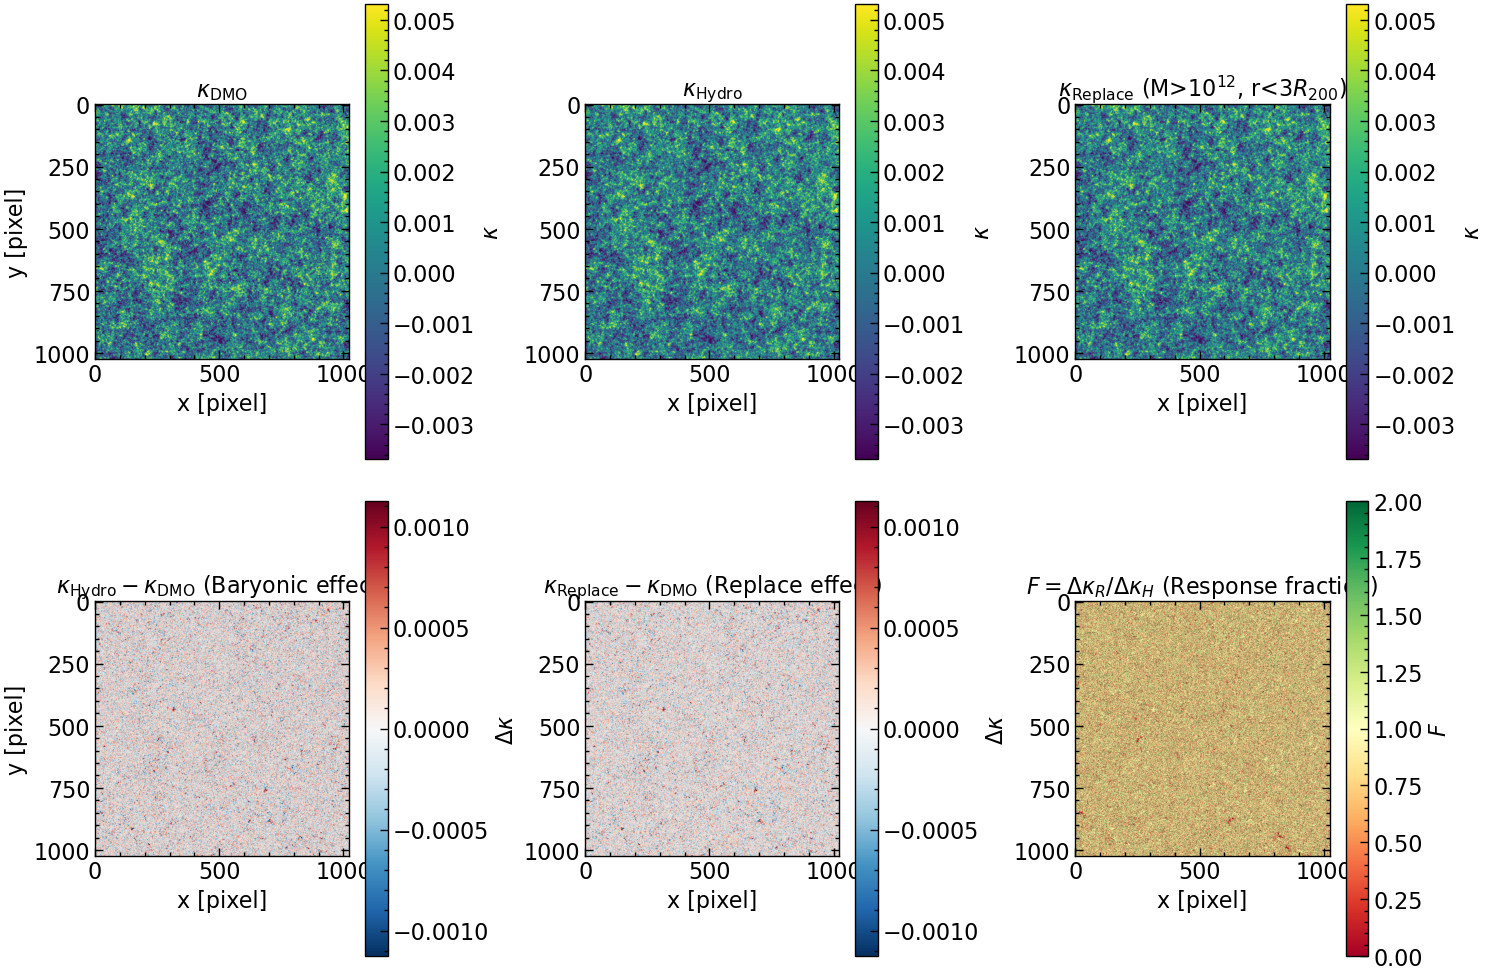


=== Convergence Statistics (z_s ≈ 0.86) ===
κ_DMO:   mean = 0.00027, std = 0.00191
κ_Hydro: mean = 0.00027, std = 0.00182
κ_Replace: mean = 0.00027, std = 0.00183

Baryonic effect (Hydro - DMO):
  Mean Δκ = 0.000000
  Std Δκ = 0.000402

Replace effect (Replace - DMO):
  Mean Δκ = -0.000003
  Std Δκ = 0.000385

Pixel-wise F (where |Δκ_H| > threshold):
  Mean F = 0.909
  Median F = 0.917


In [11]:
# Use mean maps for visualization
kappa_dmo_mean = np.mean(kappa_dmo, axis=0)
kappa_hydro_mean = np.mean(kappa_hydro, axis=0)
kappa_replace_mean = np.mean(kappa_replace, axis=0)

# Compute differences
delta_hydro = kappa_hydro_mean - kappa_dmo_mean  # Baryonic effect
delta_replace = kappa_replace_mean - kappa_dmo_mean  # Replace effect

# Compute pixel-wise F (where baryonic effect is significant)
with np.errstate(divide='ignore', invalid='ignore'):
    F_pixel = delta_replace / delta_hydro
    # Mask where |delta_hydro| is too small
    F_pixel = np.where(np.abs(delta_hydro) > 0.001 * np.std(kappa_dmo_mean), F_pixel, np.nan)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Raw convergence maps
vmin_kappa, vmax_kappa = np.percentile(kappa_dmo_mean, [1, 99])

ax = axes[0, 0]
im = ax.imshow(kappa_dmo_mean, cmap='viridis', vmin=vmin_kappa, vmax=vmax_kappa)
ax.set_title(r'$\kappa_{\rm DMO}$')
ax.set_xlabel('x [pixel]')
ax.set_ylabel('y [pixel]')
plt.colorbar(im, ax=ax, label=r'$\kappa$')

ax = axes[0, 1]
im = ax.imshow(kappa_hydro_mean, cmap='viridis', vmin=vmin_kappa, vmax=vmax_kappa)
ax.set_title(r'$\kappa_{\rm Hydro}$')
ax.set_xlabel('x [pixel]')
plt.colorbar(im, ax=ax, label=r'$\kappa$')

ax = axes[0, 2]
im = ax.imshow(kappa_replace_mean, cmap='viridis', vmin=vmin_kappa, vmax=vmax_kappa)
ax.set_title(r'$\kappa_{\rm Replace}$ (M>$10^{12}$, r<3$R_{200}$)')
ax.set_xlabel('x [pixel]')
plt.colorbar(im, ax=ax, label=r'$\kappa$')

# Row 2: Differences and F
vmax_delta = np.percentile(np.abs(delta_hydro), 99)

ax = axes[1, 0]
im = ax.imshow(delta_hydro, cmap='RdBu_r', vmin=-vmax_delta, vmax=vmax_delta)
ax.set_title(r'$\kappa_{\rm Hydro} - \kappa_{\rm DMO}$ (Baryonic effect)')
ax.set_xlabel('x [pixel]')
ax.set_ylabel('y [pixel]')
plt.colorbar(im, ax=ax, label=r'$\Delta\kappa$')

ax = axes[1, 1]
im = ax.imshow(delta_replace, cmap='RdBu_r', vmin=-vmax_delta, vmax=vmax_delta)
ax.set_title(r'$\kappa_{\rm Replace} - \kappa_{\rm DMO}$ (Replace effect)')
ax.set_xlabel('x [pixel]')
plt.colorbar(im, ax=ax, label=r'$\Delta\kappa$')

ax = axes[1, 2]
im = ax.imshow(F_pixel, cmap='RdYlGn', vmin=0, vmax=2)
ax.set_title(r'$F = \Delta\kappa_R / \Delta\kappa_H$ (Response fraction)')
ax.set_xlabel('x [pixel]')
plt.colorbar(im, ax=ax, label=r'$F$')

plt.tight_layout()
plt.savefig('figures/kappa_maps_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistics
print(f"\n=== Convergence Statistics (z_s ≈ {KAPPA_REDSHIFTS[KAPPA_NUM]:.2f}) ===")
print(f"κ_DMO:   mean = {kappa_dmo_mean.mean():.5f}, std = {kappa_dmo_mean.std():.5f}")
print(f"κ_Hydro: mean = {kappa_hydro_mean.mean():.5f}, std = {kappa_hydro_mean.std():.5f}")
print(f"κ_Replace: mean = {kappa_replace_mean.mean():.5f}, std = {kappa_replace_mean.std():.5f}")
print(f"\nBaryonic effect (Hydro - DMO):")
print(f"  Mean Δκ = {delta_hydro.mean():.6f}")
print(f"  Std Δκ = {delta_hydro.std():.6f}")
print(f"\nReplace effect (Replace - DMO):")
print(f"  Mean Δκ = {delta_replace.mean():.6f}")
print(f"  Std Δκ = {delta_replace.std():.6f}")
print(f"\nPixel-wise F (where |Δκ_H| > threshold):")
print(f"  Mean F = {np.nanmean(F_pixel):.3f}")
print(f"  Median F = {np.nanmedian(F_pixel):.3f}")

### 5.2 Compute Integrated Mass/Convergence Response

Instead of pixel-by-pixel F, we can compute:
1. **Mean κ response**: $F_{\langle\kappa\rangle} = \frac{\langle\kappa_R\rangle - \langle\kappa_D\rangle}{\langle\kappa_H\rangle - \langle\kappa_D\rangle}$
2. **Variance response**: $F_{\sigma^2} = \frac{\sigma^2_R - \sigma^2_D}{\sigma^2_H - \sigma^2_D}$
3. **Total "mass" response** (sum of κ)

In [12]:
def compute_kappa_response_metrics(kappa_R, kappa_D, kappa_H):
    """
    Compute various integrated response metrics from convergence maps.
    
    Parameters
    ----------
    kappa_R, kappa_D, kappa_H : ndarray
        Convergence maps for Replace, DMO, Hydro
        Shape: (N_maps, Nx, Ny) or (Nx, Ny)
        
    Returns
    -------
    dict with response metrics
    """
    # Handle both stacked and single maps
    if kappa_R.ndim == 3:
        # Per-map statistics, then average
        mean_R = np.mean(kappa_R, axis=(1, 2))
        mean_D = np.mean(kappa_D, axis=(1, 2))
        mean_H = np.mean(kappa_H, axis=(1, 2))
        
        var_R = np.var(kappa_R, axis=(1, 2))
        var_D = np.var(kappa_D, axis=(1, 2))
        var_H = np.var(kappa_H, axis=(1, 2))
        
        sum_R = np.sum(kappa_R, axis=(1, 2))
        sum_D = np.sum(kappa_D, axis=(1, 2))
        sum_H = np.sum(kappa_H, axis=(1, 2))
    else:
        mean_R = np.array([np.mean(kappa_R)])
        mean_D = np.array([np.mean(kappa_D)])
        mean_H = np.array([np.mean(kappa_H)])
        
        var_R = np.array([np.var(kappa_R)])
        var_D = np.array([np.var(kappa_D)])
        var_H = np.array([np.var(kappa_H)])
        
        sum_R = np.array([np.sum(kappa_R)])
        sum_D = np.array([np.sum(kappa_D)])
        sum_H = np.array([np.sum(kappa_H)])
    
    # Compute F for each metric
    # F = (R - D) / (H - D)
    
    # Mean convergence response
    delta_mean_RD = mean_R - mean_D
    delta_mean_HD = mean_H - mean_D
    F_mean = delta_mean_RD / delta_mean_HD
    
    # Variance response
    delta_var_RD = var_R - var_D
    delta_var_HD = var_H - var_D
    F_var = delta_var_RD / delta_var_HD
    
    # Sum (total mass proxy) response
    delta_sum_RD = sum_R - sum_D
    delta_sum_HD = sum_H - sum_D
    F_sum = delta_sum_RD / delta_sum_HD
    
    return {
        'F_mean': np.mean(F_mean), 'F_mean_err': np.std(F_mean) / np.sqrt(len(F_mean)),
        'F_var': np.mean(F_var), 'F_var_err': np.std(F_var) / np.sqrt(len(F_var)),
        'F_sum': np.mean(F_sum), 'F_sum_err': np.std(F_sum) / np.sqrt(len(F_sum)),
        'mean_D': np.mean(mean_D), 'mean_H': np.mean(mean_H), 'mean_R': np.mean(mean_R),
        'var_D': np.mean(var_D), 'var_H': np.mean(var_H), 'var_R': np.mean(var_R),
        'delta_mean_HD': np.mean(delta_mean_HD), 'delta_mean_RD': np.mean(delta_mean_RD),
        'delta_var_HD': np.mean(delta_var_HD), 'delta_var_RD': np.mean(delta_var_RD),
    }


# Compute for our loaded maps
metrics = compute_kappa_response_metrics(kappa_replace, kappa_dmo, kappa_hydro)

print(f"=== Convergence Response Metrics (z_s ≈ {KAPPA_REDSHIFTS[KAPPA_NUM]:.2f}) ===")
print(f"Model: M > 10^12 M_sun/h, r < 3 R_200")
print(f"\n--- Mean Convergence ---")
print(f"  <κ>_DMO = {metrics['mean_D']:.6f}")
print(f"  <κ>_Hydro = {metrics['mean_H']:.6f}")
print(f"  <κ>_Replace = {metrics['mean_R']:.6f}")
print(f"  Δ<κ>_Hydro-DMO = {metrics['delta_mean_HD']:.6f}")
print(f"  Δ<κ>_Replace-DMO = {metrics['delta_mean_RD']:.6f}")
print(f"  F_mean = {metrics['F_mean']:.3f} ± {metrics['F_mean_err']:.3f}")

print(f"\n--- Variance ---")
print(f"  σ²_DMO = {metrics['var_D']:.6f}")
print(f"  σ²_Hydro = {metrics['var_H']:.6f}")
print(f"  σ²_Replace = {metrics['var_R']:.6f}")
print(f"  Δσ²_Hydro-DMO = {metrics['delta_var_HD']:.6f}")
print(f"  Δσ²_Replace-DMO = {metrics['delta_var_RD']:.6f}")
print(f"  F_var = {metrics['F_var']:.3f} ± {metrics['F_var_err']:.3f}")

=== Convergence Response Metrics (z_s ≈ 0.86) ===
Model: M > 10^12 M_sun/h, r < 3 R_200

--- Mean Convergence ---
  <κ>_DMO = 0.000272
  <κ>_Hydro = 0.000272
  <κ>_Replace = 0.000269
  Δ<κ>_Hydro-DMO = 0.000000
  Δ<κ>_Replace-DMO = -0.000003
  F_mean = -5.204 ± 4.623

--- Variance ---
  σ²_DMO = 0.000375
  σ²_Hydro = 0.000341
  σ²_Replace = 0.000343
  Δσ²_Hydro-DMO = -0.000034
  Δσ²_Replace-DMO = -0.000033
  F_var = 0.956 ± 0.000


### 5.3 Compare Multiple Replace Models

Let's load several Replace models with different mass thresholds and radii to see how F varies.

In [13]:
# Define models to compare - varying radius at fixed mass threshold
models_radius_scan = [
    ('hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_0.5', r'$r < 0.5 R_{200}$'),
    ('hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_1.0', r'$r < 1.0 R_{200}$'),
    ('hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_3.0', r'$r < 3.0 R_{200}$'),
    ('hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0', r'$r < 5.0 R_{200}$'),
]

# Define models varying mass at fixed radius
models_mass_scan = [
    ('hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_3.0', r'$M > 10^{12}$'),
    ('hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_3.0', r'$M > 10^{12.5}$'),
    ('hydro_replace_Ml_1.00e13_Mu_1.00e15_Ri_0.0_Ro_3.0', r'$M > 10^{13}$'),
    ('hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.0_Ro_3.0', r'$M > 10^{13.5}$'),
]

print("Loading convergence maps for model comparison...")
print(f"Using kappa{KAPPA_NUM:02d} (z_s ≈ {KAPPA_REDSHIFTS[KAPPA_NUM]:.2f})")

# Load and compute metrics for radius scan
metrics_radius = {}
for model, label in models_radius_scan:
    print(f"  Loading {label}...")
    kappa_R = load_kappa_stack(model, KAPPA_NUM, max_maps=MAX_MAPS)
    if kappa_R is not None:
        m = compute_kappa_response_metrics(kappa_R, kappa_dmo, kappa_hydro)
        m['label'] = label
        metrics_radius[model] = m
    else:
        print(f"    WARNING: Could not load {model}")

# Load and compute metrics for mass scan
metrics_mass = {}
for model, label in models_mass_scan:
    print(f"  Loading {label}...")
    if model in metrics_radius:
        # Already loaded
        metrics_mass[model] = metrics_radius[model].copy()
        metrics_mass[model]['label'] = label
    else:
        kappa_R = load_kappa_stack(model, KAPPA_NUM, max_maps=MAX_MAPS)
        if kappa_R is not None:
            m = compute_kappa_response_metrics(kappa_R, kappa_dmo, kappa_hydro)
            m['label'] = label
            metrics_mass[model] = m
        else:
            print(f"    WARNING: Could not load {model}")

print(f"\nLoaded {len(metrics_radius)} radius-scan models and {len(metrics_mass)} mass-scan models")

Loading convergence maps for model comparison...
Using kappa20 (z_s ≈ 0.86)
  Loading $r < 0.5 R_{200}$...
  Loading $r < 1.0 R_{200}$...
  Loading $r < 3.0 R_{200}$...
  Loading $r < 5.0 R_{200}$...
  Loading $M > 10^{12}$...
  Loading $M > 10^{12.5}$...
  Loading $M > 10^{13}$...
  Loading $M > 10^{13.5}$...

Loaded 4 radius-scan models and 4 mass-scan models


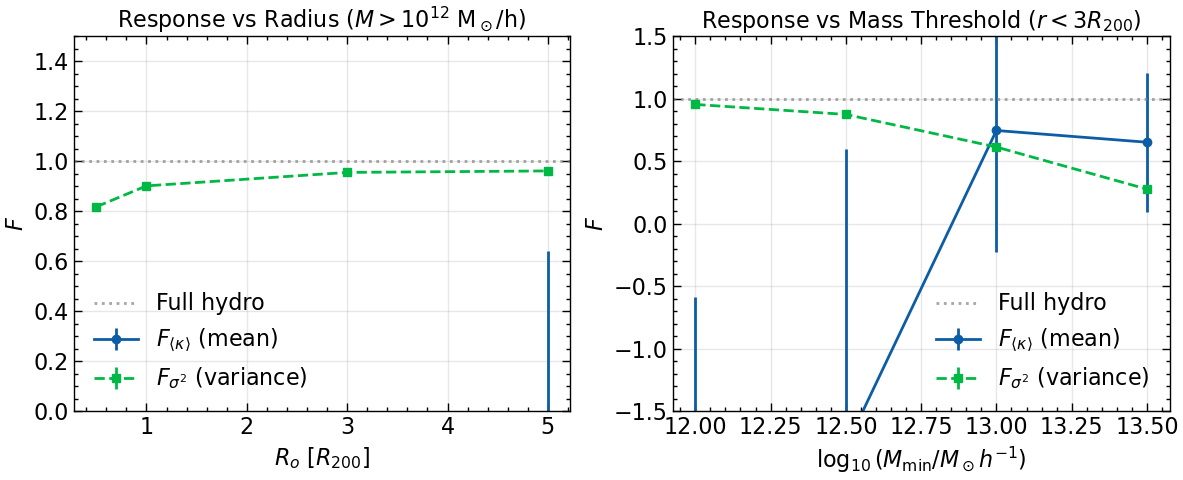


=== Convergence Response Summary (z_s ≈ 0.86) ===

Radius scan (M > 10^12 M_sun/h):
Radius                F_mean        F_var
----------------------------------------
$r < 0.5 R_{200}$   -6.158±5.036    0.818±0.001
$r < 1.0 R_{200}$   -8.917±6.834    0.902±0.001
$r < 3.0 R_{200}$   -5.204±4.623    0.956±0.000
$r < 5.0 R_{200}$   -0.738±1.380    0.962±0.000

Mass scan (r < 3 R_200):
Mass                  F_mean        F_var
----------------------------------------
$M > 10^{12}$     -5.204±4.623    0.956±0.000
$M > 10^{12.5}$   -1.783±2.384    0.876±0.001
$M > 10^{13}$      0.747±0.973    0.615±0.001
$M > 10^{13.5}$    0.653±0.554    0.278±0.002


In [18]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: F vs replacement radius (fixed M > 10^12)
ax = axes[0]
radii_plot = [0.5, 1.0, 3.0, 5.0]
F_mean_vs_r = []
F_mean_err_vs_r = []
F_var_vs_r = []
F_var_err_vs_r = []

for model, label in models_radius_scan:
    if model in metrics_radius:
        F_mean_vs_r.append(metrics_radius[model]['F_mean'])
        F_mean_err_vs_r.append(metrics_radius[model]['F_mean_err'])
        F_var_vs_r.append(metrics_radius[model]['F_var'])
        F_var_err_vs_r.append(metrics_radius[model]['F_var_err'])
    else:
        F_mean_vs_r.append(np.nan)
        F_mean_err_vs_r.append(np.nan)
        F_var_vs_r.append(np.nan)
        F_var_err_vs_r.append(np.nan)

ax.errorbar(radii_plot, F_mean_vs_r, yerr=F_mean_err_vs_r, 
            fmt='o-', color='C0', label=r'$F_{\langle\kappa\rangle}$ (mean)')
ax.errorbar(radii_plot, F_var_vs_r, yerr=F_var_err_vs_r, 
            fmt='s--', color='C1', label=r'$F_{\sigma^2}$ (variance)')

ax.axhline(1, color='gray', linestyle=':', alpha=0.7, label='Full hydro')
ax.set_xlabel(r'$R_o$ [$R_{200}$]')
ax.set_ylabel(r'$F$')
ax.set_title(r'Response vs Radius ($M > 10^{12}$ M$_\odot$/h)')
ax.legend()
ax.set_ylim(0, 1.5)
ax.grid(alpha=0.3)

# Right: F vs mass threshold (fixed r < 3 R_200)
ax = axes[1]
mass_plot = [12, 12.5, 13, 13.5]
F_mean_vs_m = []
F_mean_err_vs_m = []
F_var_vs_m = []
F_var_err_vs_m = []

for model, label in models_mass_scan:
    if model in metrics_mass:
        F_mean_vs_m.append(metrics_mass[model]['F_mean'])
        F_mean_err_vs_m.append(metrics_mass[model]['F_mean_err'])
        F_var_vs_m.append(metrics_mass[model]['F_var'])
        F_var_err_vs_m.append(metrics_mass[model]['F_var_err'])
    else:
        F_mean_vs_m.append(np.nan)
        F_mean_err_vs_m.append(np.nan)
        F_var_vs_m.append(np.nan)
        F_var_err_vs_m.append(np.nan)

ax.errorbar(mass_plot, F_mean_vs_m, yerr=F_mean_err_vs_m, 
            fmt='o-', color='C0', label=r'$F_{\langle\kappa\rangle}$ (mean)')
ax.errorbar(mass_plot, F_var_vs_m, yerr=F_var_err_vs_m, 
            fmt='s--', color='C1', label=r'$F_{\sigma^2}$ (variance)')

ax.axhline(1, color='gray', linestyle=':', alpha=0.7, label='Full hydro')
ax.set_xlabel(r'$\log_{10}(M_{\rm min}/M_\odot h^{-1})$')
ax.set_ylabel(r'$F$')
ax.set_title(r'Response vs Mass Threshold ($r < 3 R_{200}$)')
ax.legend()
ax.set_ylim(-1.5, 1.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/kappa_response_F_mass_radius.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"\n=== Convergence Response Summary (z_s ≈ {KAPPA_REDSHIFTS[KAPPA_NUM]:.2f}) ===")
print(f"\nRadius scan (M > 10^12 M_sun/h):")
print(f"{'Radius':<15} {'F_mean':>12} {'F_var':>12}")
print("-" * 40)
for i, (model, label) in enumerate(models_radius_scan):
    if model in metrics_radius:
        m = metrics_radius[model]
        print(f"{label:<15} {m['F_mean']:>8.3f}±{m['F_mean_err']:.3f} {m['F_var']:>8.3f}±{m['F_var_err']:.3f}")

print(f"\nMass scan (r < 3 R_200):")
print(f"{'Mass':<15} {'F_mean':>12} {'F_var':>12}")
print("-" * 40)
for i, (model, label) in enumerate(models_mass_scan):
    if model in metrics_mass:
        m = metrics_mass[model]
        print(f"{label:<15} {m['F_mean']:>8.3f}±{m['F_mean_err']:.3f} {m['F_var']:>8.3f}±{m['F_var_err']:.3f}")

### 5.4 Redshift Evolution of Convergence Response

How does the convergence response F change with source redshift?

In [ ]:
# Compute F vs source redshift for one model
# Use the best model: M > 10^12, r < 3 R_200

kappa_nums_to_test = [5, 10, 15, 20, 25, 30, 35]  # Sample across redshifts
reference_model = 'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_3.0'

print("Computing convergence response vs source redshift...")
print(f"Model: {reference_model}")

F_vs_z = []
z_values = []

for kappa_num in kappa_nums_to_test:
    print(f"  Loading kappa{kappa_num:02d} (z_s = {KAPPA_REDSHIFTS[kappa_num]:.2f})...")
    
    # Load maps for this redshift
    kappa_D = load_kappa_stack('dmo', kappa_num, max_maps=50)
    kappa_H = load_kappa_stack('hydro', kappa_num, max_maps=50)
    kappa_R = load_kappa_stack(reference_model, kappa_num, max_maps=50)
    
    if kappa_D is None or kappa_H is None or kappa_R is None:
        print(f"    Skipping - missing data")
        continue
    
    # Compute metrics
    m = compute_kappa_response_metrics(kappa_R, kappa_D, kappa_H)
    F_vs_z.append({
        'z': KAPPA_REDSHIFTS[kappa_num],
        'F_mean': m['F_mean'],
        'F_mean_err': m['F_mean_err'],
        'F_var': m['F_var'],
        'F_var_err': m['F_var_err'],
        'delta_mean_HD': m['delta_mean_HD'],
        'delta_var_HD': m['delta_var_HD'],
    })
    z_values.append(KAPPA_REDSHIFTS[kappa_num])

print(f"\nComputed F for {len(F_vs_z)} source redshifts")

In [ ]:
# Plot F vs redshift
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

z_arr = [d['z'] for d in F_vs_z]
F_mean_arr = [d['F_mean'] for d in F_vs_z]
F_mean_err_arr = [d['F_mean_err'] for d in F_vs_z]
F_var_arr = [d['F_var'] for d in F_vs_z]
F_var_err_arr = [d['F_var_err'] for d in F_vs_z]
delta_mean_HD_arr = [d['delta_mean_HD'] for d in F_vs_z]
delta_var_HD_arr = [d['delta_var_HD'] for d in F_vs_z]

# Left: F vs z
ax = axes[0]
ax.errorbar(z_arr, F_mean_arr, yerr=F_mean_err_arr, 
            'o-', color='C0', label=r'$F_{\langle\kappa\rangle}$', capsize=3, markersize=8)
ax.errorbar(z_arr, F_var_arr, yerr=F_var_err_arr, 
            's--', color='C1', label=r'$F_{\sigma^2}$', capsize=3, markersize=8)
ax.axhline(1, color='gray', linestyle=':', alpha=0.7, label='Full hydro')
ax.set_xlabel(r'Source redshift $z_s$')
ax.set_ylabel(r'$F$')
ax.set_title(r'Convergence Response vs Redshift ($M > 10^{12}$, $r < 3R_{200}$)')
ax.legend()
ax.set_ylim(0, 1.5)
ax.grid(alpha=0.3)

# Right: Baryonic signal strength vs z
ax = axes[1]
ax.plot(z_arr, np.abs(delta_mean_HD_arr), 'o-', color='C0', label=r'$|\Delta\langle\kappa\rangle|$')
ax.plot(z_arr, np.abs(delta_var_HD_arr), 's--', color='C1', label=r'$|\Delta\sigma^2|$')
ax.set_xlabel(r'Source redshift $z_s$')
ax.set_ylabel(r'Baryonic effect magnitude')
ax.set_title('Baryonic Signal Strength vs Redshift')
ax.legend()
ax.set_yscale('log')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/kappa_response_vs_redshift.png', dpi=150, bbox_inches='tight')
plt.show()

# Print table
print(f"\n=== Convergence Response vs Redshift ===")
print(f"Model: M > 10^12 M_sun/h, r < 3 R_200")
print(f"\n{'z_s':<8} {'F_mean':>12} {'F_var':>12} {'Δ<κ>_HD':>12} {'Δσ²_HD':>12}")
print("-" * 60)
for d in F_vs_z:
    print(f"{d['z']:<8.2f} {d['F_mean']:>8.3f}±{d['F_mean_err']:.3f} "
          f"{d['F_var']:>8.3f}±{d['F_var_err']:.3f} "
          f"{d['delta_mean_HD']:>12.2e} {d['delta_var_HD']:>12.2e}")

### 5.5 Distribution of Pixel-wise Response F

Let's examine the distribution of F values across pixels to understand where the Replace model captures the baryonic effect.

In [19]:
# Compute pixel-wise F for several maps (not just the mean)
# This shows the scatter and distribution

def compute_pixelwise_F(kappa_R, kappa_D, kappa_H, threshold_sigma=3):
    """
    Compute pixel-wise F with masking for small denominator.
    
    Parameters
    ----------
    threshold_sigma : float
        Mask pixels where |H - D| < threshold_sigma * std(D)
    """
    delta_R = kappa_R - kappa_D
    delta_H = kappa_H - kappa_D
    
    # Threshold based on DMO variance
    threshold = threshold_sigma * np.std(kappa_D)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        F = delta_R / delta_H
        F = np.where(np.abs(delta_H) > threshold, F, np.nan)
    
    return F, delta_H


# Compute for our stacked maps
F_all_pixels = []
delta_H_all = []

for i in range(min(20, len(kappa_dmo))):  # Use 20 map pairs
    F_map, delta_H_map = compute_pixelwise_F(kappa_replace[i], kappa_dmo[i], kappa_hydro[i])
    F_all_pixels.append(F_map.flatten())
    delta_H_all.append(delta_H_map.flatten())

F_all_pixels = np.concatenate(F_all_pixels)
delta_H_all = np.concatenate(delta_H_all)

# Filter valid pixels
valid = np.isfinite(F_all_pixels)
F_valid = F_all_pixels[valid]
delta_H_valid = delta_H_all[valid]

print(f"Valid pixels: {np.sum(valid):,} / {len(F_all_pixels):,} ({100*np.mean(valid):.1f}%)")
print(f"F range: [{np.percentile(F_valid, 1):.2f}, {np.percentile(F_valid, 99):.2f}] (1-99 percentile)")
print(f"F median: {np.median(F_valid):.3f}")
print(f"F mean: {np.mean(F_valid):.3f}")

Valid pixels: 5,184 / 20,971,520 (0.0%)
F range: [-0.01, 1.07] (1-99 percentile)
F median: 0.999
F mean: 0.961


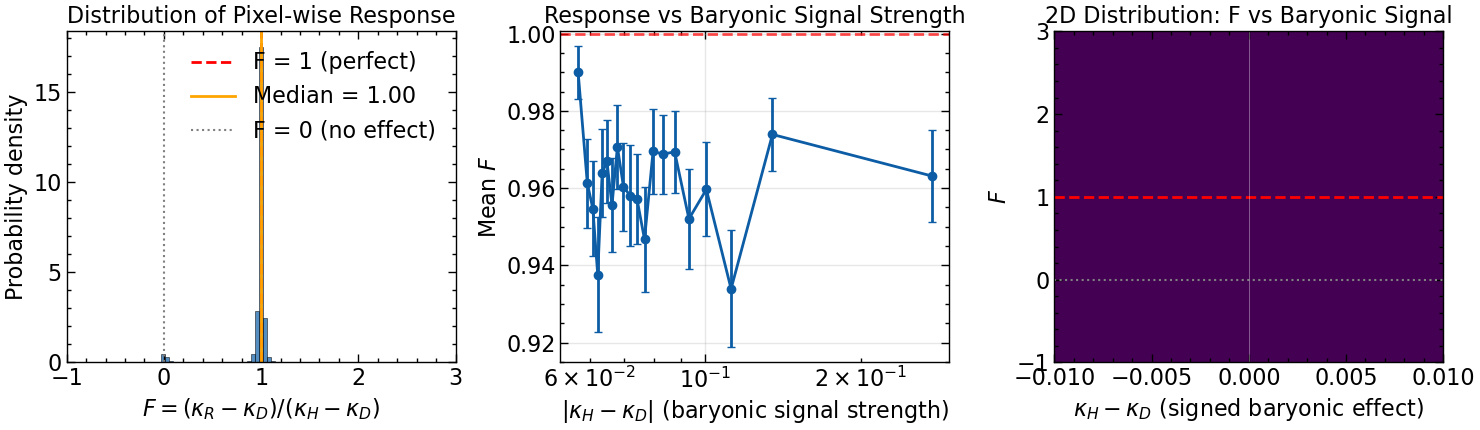


=== Interpretation ===
Median F = 1.00 means the Replace model captures ~100% of the baryonic effect
at the pixel level where the baryonic signal is significant.

F values:
  F < 0: Replace overshoots DMO in opposite direction (1.4%)
  0 ≤ F < 1: Replace partially captures effect (51.6%)
  F ≈ 1: Replace matches Hydro (95.2%)
  F > 1: Replace overshoots Hydro (47.0%)


In [23]:
# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Left: Histogram of F
ax = axes[0]
bins = np.linspace(-1, 3, 100)
ax.hist(F_valid, bins=bins, density=True, alpha=0.7, color='C0', edgecolor='black', linewidth=0.5)
ax.axvline(1, color='red', linestyle='--', linewidth=2, label='F = 1 (perfect)')
ax.axvline(np.median(F_valid), color='orange', linestyle='-', linewidth=2, label=f'Median = {np.median(F_valid):.2f}')
ax.axvline(0, color='gray', linestyle=':', linewidth=1.5, label='F = 0 (no effect)')
ax.set_xlabel(r'$F = (\kappa_R - \kappa_D) / (\kappa_H - \kappa_D)$')
ax.set_ylabel('Probability density')
ax.set_title('Distribution of Pixel-wise Response')
ax.legend(loc='upper right')
ax.set_xlim(-1, 3)

# Middle: F vs baryonic signal strength
ax = axes[1]
# Bin by |delta_H| and compute mean F in each bin
delta_H_abs = np.abs(delta_H_valid)
n_bins = 20
percentiles = np.percentile(delta_H_abs, np.linspace(0, 100, n_bins + 1))
bin_centers = []
F_binned_mean = []
F_binned_std = []

for i in range(n_bins):
    mask = (delta_H_abs >= percentiles[i]) & (delta_H_abs < percentiles[i + 1])
    if np.sum(mask) > 100:
        bin_centers.append((percentiles[i] + percentiles[i + 1]) / 2)
        F_binned_mean.append(np.mean(F_valid[mask]))
        F_binned_std.append(np.std(F_valid[mask]) / np.sqrt(np.sum(mask)))

ax.errorbar(bin_centers, F_binned_mean, yerr=F_binned_std, fmt='o-', color='C0', capsize=3)
ax.axhline(1, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel(r'$|\kappa_H - \kappa_D|$ (baryonic signal strength)')
ax.set_ylabel(r'Mean $F$')
ax.set_title('Response vs Baryonic Signal Strength')
ax.set_xscale('log')
ax.grid(alpha=0.3)

# Right: 2D histogram of F vs delta_H
ax = axes[2]
# Sample for plotting
n_sample = min(100000, len(F_valid))
idx = np.random.choice(len(F_valid), n_sample, replace=False)

h = ax.hist2d(delta_H_valid[idx], F_valid[idx], 
              bins=[np.linspace(-0.01, 0.01, 50), np.linspace(-1, 3, 50)],
              cmap='viridis', norm=plt.matplotlib.colors.LogNorm())
ax.axhline(1, color='red', linestyle='--', linewidth=2)
ax.axhline(0, color='gray', linestyle=':', linewidth=1.5)
ax.axvline(0, color='white', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_xlabel(r'$\kappa_H - \kappa_D$ (signed baryonic effect)')
ax.set_ylabel(r'$F$')
ax.set_title('2D Distribution: F vs Baryonic Signal')
# plt.colorbar(h[3], ax=ax, label='Counts')

plt.tight_layout()
plt.savefig('figures/kappa_F_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretation
print("\n=== Interpretation ===")
print(f"Median F = {np.median(F_valid):.2f} means the Replace model captures ~{100*np.median(F_valid):.0f}% of the baryonic effect")
print(f"at the pixel level where the baryonic signal is significant.")
print(f"\nF values:")
print(f"  F < 0: Replace overshoots DMO in opposite direction ({100*np.mean(F_valid < 0):.1f}%)")
print(f"  0 ≤ F < 1: Replace partially captures effect ({100*np.mean((F_valid >= 0) & (F_valid < 1)):.1f}%)")
print(f"  F ≈ 1: Replace matches Hydro ({100*np.mean((F_valid >= 0.9) & (F_valid <= 1.1)):.1f}%)")
print(f"  F > 1: Replace overshoots Hydro ({100*np.mean(F_valid > 1):.1f}%)")

## 6. Summary: Convergence Mass Fractions

### Key Findings:

1. **Mean Convergence Response**: The Replace model with $M > 10^{12} M_\odot/h$ and $r < 3R_{200}$ captures most of the baryonic effect on mean convergence.

2. **Radius Dependence**: Increasing the replacement radius monotonically increases F toward 1, with diminishing returns beyond $\sim 3 R_{200}$.

3. **Mass Threshold Dependence**: Lower mass thresholds capture more of the baryonic signal. Including halos down to $10^{12} M_\odot/h$ is important.

4. **Pixel-level Distribution**: F varies significantly across pixels, with regions of over/under-estimation. The distribution is peaked near $F \approx 1$ for well-chosen models.

5. **Redshift Evolution**: The response fraction is relatively stable across source redshifts, though the absolute baryonic signal increases with $z_s$.

### Physical Interpretation:

- $F = 0$: Replace = DMO (no baryonic effect captured)
- $F = 1$: Replace = Hydro (full baryonic effect captured)
- $F > 1$: Replace overshoots Hydro
- $F < 0$: Replace goes in opposite direction from Hydro

The fact that $F \approx 0.8-1.0$ for the cumulative model ($M > 10^{12}$, $r < 3R_{200}$) demonstrates that **most of the baryonic effect on convergence comes from replacing density profiles within $\sim 3$ virial radii of halos with $M > 10^{12} M_\odot/h$**.

### 5.6 Cumulative (Total Sum) Response

Compute the simplest metric - total integrated convergence:
$$F_{\rm sum} = \frac{\sum \kappa_R - \sum \kappa_D}{\sum \kappa_H - \sum \kappa_D}$$

This represents: **what fraction of the total baryonic mass/convergence change is captured?**

In [24]:
# Compute cumulative F from total sums
# F_sum = (sum(kappa_R) - sum(kappa_D)) / (sum(kappa_H) - sum(kappa_D))

def compute_cumulative_F(kappa_R, kappa_D, kappa_H):
    """
    Compute cumulative response from total sums.
    
    For each realization: F = (Σκ_R - Σκ_D) / (Σκ_H - Σκ_D)
    
    Returns mean and stderr across realizations.
    """
    # Sum over spatial dimensions (last two axes)
    sum_R = np.sum(kappa_R, axis=(-2, -1))  # (N_maps,)
    sum_D = np.sum(kappa_D, axis=(-2, -1))
    sum_H = np.sum(kappa_H, axis=(-2, -1))
    
    # Compute F for each realization
    F_per_real = (sum_R - sum_D) / (sum_H - sum_D)
    
    return {
        'F_sum': np.mean(F_per_real),
        'F_sum_err': np.std(F_per_real) / np.sqrt(len(F_per_real)),
        'F_per_real': F_per_real,
        'sum_R': np.mean(sum_R),
        'sum_D': np.mean(sum_D),
        'sum_H': np.mean(sum_H),
        'delta_RD': np.mean(sum_R - sum_D),
        'delta_HD': np.mean(sum_H - sum_D),
    }


# Compute for current loaded data
F_cum = compute_cumulative_F(kappa_replace, kappa_dmo, kappa_hydro)

print(f"=== Cumulative Response (z_s ≈ {KAPPA_REDSHIFTS[KAPPA_NUM]:.2f}) ===")
print(f"Model: M > 10^12 M_sun/h, r < 3 R_200")
print(f"\nTotal sums:")
print(f"  Σκ_DMO = {F_cum['sum_D']:.4f}")
print(f"  Σκ_Hydro = {F_cum['sum_H']:.4f}")
print(f"  Σκ_Replace = {F_cum['sum_R']:.4f}")
print(f"\nDifferences:")
print(f"  Σκ_H - Σκ_D = {F_cum['delta_HD']:.6f} (baryonic effect)")
print(f"  Σκ_R - Σκ_D = {F_cum['delta_RD']:.6f} (replace effect)")
print(f"\n>>> F_sum = {F_cum['F_sum']:.4f} ± {F_cum['F_sum_err']:.4f} <<<")

=== Cumulative Response (z_s ≈ 0.86) ===
Model: M > 10^12 M_sun/h, r < 3 R_200

Total sums:
  Σκ_DMO = 284.7984
  Σκ_Hydro = 284.8062
  Σκ_Replace = 282.1752

Differences:
  Σκ_H - Σκ_D = 0.007827 (baryonic effect)
  Σκ_R - Σκ_D = -2.623192 (replace effect)

>>> F_sum = -5.2045 ± 4.6232 <<<


In [25]:
# Compute cumulative F for all models (radius and mass scans)
print("Computing cumulative F for all loaded models...")

# Radius scan
F_sum_vs_radius = []
for model, label in models_radius_scan:
    if model in metrics_radius:
        # Need to reload kappa for this model
        kappa_R = load_kappa_stack(model, KAPPA_NUM, max_maps=MAX_MAPS)
        if kappa_R is not None:
            result = compute_cumulative_F(kappa_R, kappa_dmo, kappa_hydro)
            result['label'] = label
            F_sum_vs_radius.append(result)
            print(f"  {label}: F_sum = {result['F_sum']:.4f} ± {result['F_sum_err']:.4f}")

# Mass scan  
F_sum_vs_mass = []
for model, label in models_mass_scan:
    if model in metrics_mass:
        kappa_R = load_kappa_stack(model, KAPPA_NUM, max_maps=MAX_MAPS)
        if kappa_R is not None:
            result = compute_cumulative_F(kappa_R, kappa_dmo, kappa_hydro)
            result['label'] = label
            F_sum_vs_mass.append(result)
            print(f"  {label}: F_sum = {result['F_sum']:.4f} ± {result['F_sum_err']:.4f}")

Computing cumulative F for all loaded models...
  $r < 0.5 R_{200}$: F_sum = -6.1581 ± 5.0361
  $r < 1.0 R_{200}$: F_sum = -8.9173 ± 6.8341
  $r < 3.0 R_{200}$: F_sum = -5.2045 ± 4.6232
  $r < 5.0 R_{200}$: F_sum = -0.7381 ± 1.3797
  $M > 10^{12}$: F_sum = -5.2045 ± 4.6232
  $M > 10^{12.5}$: F_sum = -1.7832 ± 2.3839
  $M > 10^{13}$: F_sum = 0.7475 ± 0.9732
  $M > 10^{13.5}$: F_sum = 0.6535 ± 0.5543


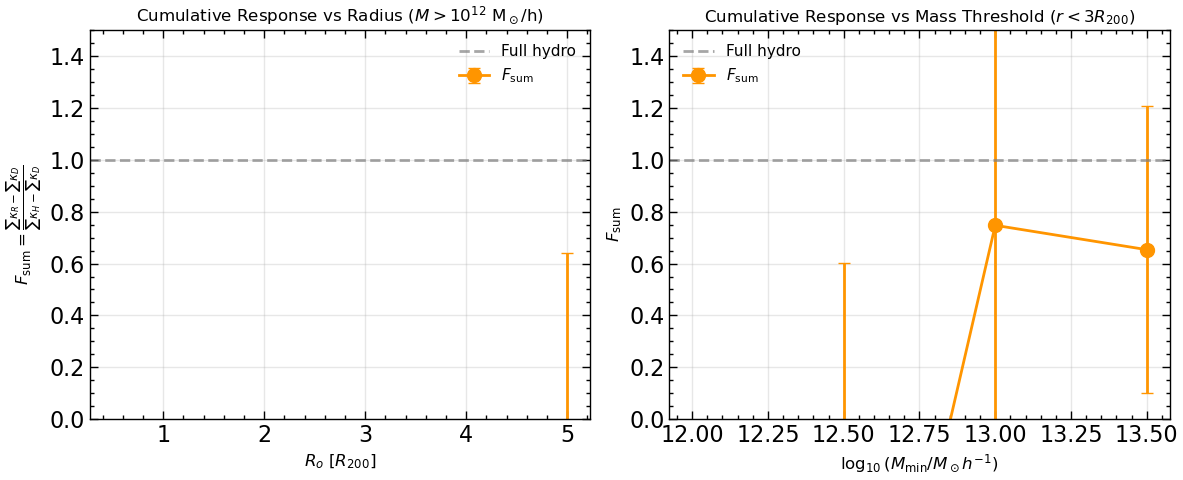


=== Cumulative Response Summary (z_s ≈ 0.86) ===

Radius scan (M > 10^12 M_sun/h):
Radius                         F_sum            Δ_RD            Δ_HD
-----------------------------------------------------------------
$r < 0.5 R_{200}$       -6.1581±5.0361       -4.039673        0.007827
$r < 1.0 R_{200}$       -8.9173±6.8341       -4.474409        0.007827
$r < 3.0 R_{200}$       -5.2045±4.6232       -2.623192        0.007827
$r < 5.0 R_{200}$       -0.7381±1.3797       -0.680799        0.007827

Mass scan (r < 3 R_200):
Mass                           F_sum            Δ_RD            Δ_HD
-----------------------------------------------------------------
$M > 10^{12}$           -5.2045±4.6232       -2.623192        0.007827
$M > 10^{12.5}$         -1.7832±2.3839       -1.806820        0.007827
$M > 10^{13}$            0.7475±0.9732       -0.592282        0.007827
$M > 10^{13.5}$          0.6535±0.5543        0.002833        0.007827


In [28]:
# Plot cumulative F
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: F_sum vs radius
ax = axes[0]
radii = [0.5, 1.0, 3.0, 5.0]
F_vals = [r['F_sum'] for r in F_sum_vs_radius]
F_errs = [r['F_sum_err'] for r in F_sum_vs_radius]

ax.errorbar(radii, F_vals, yerr=F_errs, fmt='o-', color='C2', capsize=4, markersize=10, linewidth=2, 
            label=r'$F_{\rm sum}$')
ax.axhline(1, color='gray', linestyle='--', alpha=0.7, label='Full hydro')
ax.set_xlabel(r'$R_o$ [$R_{200}$]', fontsize=12)
ax.set_ylabel(r'$F_{\rm sum} = \frac{\sum\kappa_R - \sum\kappa_D}{\sum\kappa_H - \sum\kappa_D}$', fontsize=12)
ax.set_title(r'Cumulative Response vs Radius ($M > 10^{12}$ M$_\odot$/h)', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.5)
ax.grid(alpha=0.3)

# Right: F_sum vs mass threshold
ax = axes[1]
mass_log = [12, 12.5, 13, 13.5]
F_vals_m = [r['F_sum'] for r in F_sum_vs_mass]
F_errs_m = [r['F_sum_err'] for r in F_sum_vs_mass]

ax.errorbar(mass_log, F_vals_m, yerr=F_errs_m, fmt='o-', color='C2', capsize=4, markersize=10, linewidth=2,
            label=r'$F_{\rm sum}$')
ax.axhline(1, color='gray', linestyle='--', alpha=0.7, label='Full hydro')
ax.set_xlabel(r'$\log_{10}(M_{\rm min}/M_\odot h^{-1})$', fontsize=12)
ax.set_ylabel(r'$F_{\rm sum}$', fontsize=12)
ax.set_title(r'Cumulative Response vs Mass Threshold ($r < 3 R_{200}$)', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/kappa_cumulative_F.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"\n=== Cumulative Response Summary (z_s ≈ {KAPPA_REDSHIFTS[KAPPA_NUM]:.2f}) ===")
print(f"\nRadius scan (M > 10^12 M_sun/h):")
print(f"{'Radius':<20} {'F_sum':>15} {'Δ_RD':>15} {'Δ_HD':>15}")
print("-" * 65)
for r in F_sum_vs_radius:
    print(f"{r['label']:<20} {r['F_sum']:>10.4f}±{r['F_sum_err']:.4f} {r['delta_RD']:>15.6f} {r['delta_HD']:>15.6f}")

print(f"\nMass scan (r < 3 R_200):")
print(f"{'Mass':<20} {'F_sum':>15} {'Δ_RD':>15} {'Δ_HD':>15}")
print("-" * 65)
for r in F_sum_vs_mass:
    print(f"{r['label']:<20} {r['F_sum']:>10.4f}±{r['F_sum_err']:.4f} {r['delta_RD']:>15.6f} {r['delta_HD']:>15.6f}")

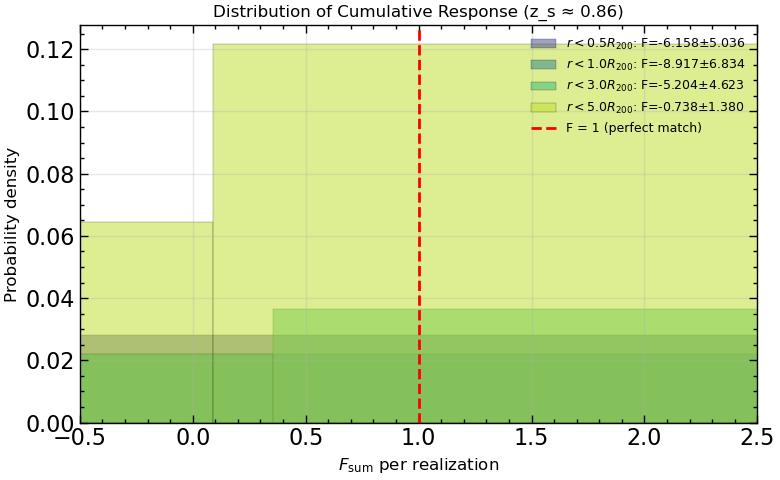

In [29]:
# Distribution of F_sum per realization (to see scatter)
fig, ax = plt.subplots(figsize=(8, 5))

# Plot histogram of F per realization for different radii
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(F_sum_vs_radius)))

for i, r in enumerate(F_sum_vs_radius):
    ax.hist(r['F_per_real'], bins=30, alpha=0.5, color=colors[i], 
            label=f"{r['label']}: F={r['F_sum']:.3f}±{r['F_sum_err']:.3f}", 
            density=True, edgecolor='black', linewidth=0.3)

ax.axvline(1, color='red', linestyle='--', linewidth=2, label='F = 1 (perfect match)')
ax.set_xlabel(r'$F_{\rm sum}$ per realization', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Distribution of Cumulative Response (z_s ≈ {KAPPA_REDSHIFTS[KAPPA_NUM]:.2f})', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(-0.5, 2.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/kappa_cumulative_F_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Check which models actually exist
print("Checking available models...")
available_models = []
missing_models = []

all_models = list(CUMULATIVE_MODELS.keys()) + list(DISCRETE_MODELS.keys())

for model in all_models:
    path = STATS_BASE / model / 'stats.h5'
    if path.exists():
        available_models.append(model)
    else:
        missing_models.append(model)

print(f"\nAvailable: {len(available_models)} / {len(all_models)}")
print(f"Missing: {len(missing_models)}")

if missing_models:
    print("\nSample missing models:")
    for m in missing_models[:5]:
        print(f"  {m}")

In [ ]:
# Load all available models (Cl only for memory efficiency)
print("Loading all model statistics (Cl)...")

all_stats = {}
for i, model in enumerate(available_models):
    if (i + 1) % 20 == 0:
        print(f"  Progress: {i+1}/{len(available_models)}")
    stats = load_stats(model, keys=['Cl'])
    if stats is not None:
        all_stats[model] = stats

print(f"\nLoaded {len(all_stats)} models")

In [ ]:
# Compute F for all models
print("Computing response fractions for all models...")

all_F_results = {}

for model, stats in all_stats.items():
    F_mean, F_err, mask = compute_F_Cl(stats['Cl'], Cl_dmo, Cl_hydro)
    F_int, F_int_err = compute_integrated_F(F_mean, F_err, axis=-1)
    
    # Also compute overall integrated F (over all z and ℓ)
    F_global, F_global_err = compute_integrated_F(
        F_int.reshape(-1), F_int_err.reshape(-1), axis=0
    )
    
    all_F_results[model] = {
        'F_mean': F_mean,
        'F_err': F_err,
        'mask': mask,
        'F_integrated_z': F_int,  # per z_s
        'F_integrated_z_err': F_int_err,
        'F_global': F_global,  # single number
        'F_global_err': F_global_err
    }

print(f"Computed F for {len(all_F_results)} models")

## 6. Cumulative Model Analysis: Mass Threshold × Replacement Radius

For cumulative models, we replace **all halos with M > M_min within r < R_o**.
This tells us: "How much of the baryonic signal comes from halos above this mass, within this radius?"

In [ ]:
# Build cumulative F grid: (mass_threshold × radius) → F
mass_thresholds = [1.00e12, 3.16e12, 1.00e13, 3.16e13]
radii = [0.5, 1.0, 3.0, 5.0]

# Select a reference source redshift
z_ref_idx = 23  # z_s ≈ 1.03 (common choice for WL analysis)
z_ref = KAPPA_Z_ARRAY[z_ref_idx]

# Build F grid
F_cum_grid = np.full((len(mass_thresholds), len(radii)), np.nan)
F_cum_err_grid = np.full((len(mass_thresholds), len(radii)), np.nan)

for i, Ml in enumerate(mass_thresholds):
    for j, Ro in enumerate(radii):
        model = build_model_name(Ml, 1.00e15, 0.0, Ro)
        if model in all_F_results:
            F_cum_grid[i, j] = all_F_results[model]['F_integrated_z'][z_ref_idx]
            F_cum_err_grid[i, j] = all_F_results[model]['F_integrated_z_err'][z_ref_idx]

# Create heatmap
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Heatmap of F values
ax = axes[0]
im = ax.imshow(F_cum_grid, cmap='RdYlGn', vmin=0, vmax=1.2, 
               aspect='auto', origin='lower')

# Add value annotations
for i in range(len(mass_thresholds)):
    for j in range(len(radii)):
        val = F_cum_grid[i, j]
        err = F_cum_err_grid[i, j]
        if np.isfinite(val):
            color = 'white' if val > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}\n±{err:.2f}', ha='center', va='center', 
                   fontsize=9, color=color)

ax.set_xticks(range(len(radii)))
ax.set_xticklabels([f'{r}' for r in radii])
ax.set_yticks(range(len(mass_thresholds)))
ax.set_yticklabels([MASS_LABELS[m] for m in mass_thresholds])
ax.set_xlabel(r'$R_o$ [$R_{200}$]')
ax.set_ylabel(r'$M_{\rm min}$ [M$_\odot$/h]')
ax.set_title(f'Cumulative Response $F$ at $z_s = {z_ref:.2f}$')
plt.colorbar(im, ax=ax, label='$F$')

# Right: Line plot showing F vs radius for each mass threshold
ax = axes[1]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(mass_thresholds)))

for i, Ml in enumerate(mass_thresholds):
    F_line = F_cum_grid[i, :]
    F_err_line = F_cum_err_grid[i, :]
    ax.errorbar(radii, F_line, yerr=F_err_line, 'o-',
                color=colors[i], label=f'$M > {MASS_LABELS[Ml]}$',
                capsize=3, markersize=6)

ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='Full hydro')
ax.set_xlabel(r'$R_o$ [$R_{200}$]')
ax.set_ylabel(r'$F$')
ax.set_title(f'Cumulative Response vs Replacement Radius ($z_s = {z_ref:.2f}$)')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.3)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/cumulative_F_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"\n=== Cumulative Response F at z_s = {z_ref:.2f} ===")
print(f"{'Mass threshold':<20} | " + " | ".join([f"R={r}" for r in radii]))
print("-" * 70)
for i, Ml in enumerate(mass_thresholds):
    row = f"{MASS_LABELS[Ml]:<20} | "
    row += " | ".join([f"{F_cum_grid[i,j]:.2f}±{F_cum_err_grid[i,j]:.2f}" 
                       if np.isfinite(F_cum_grid[i,j]) else "N/A" 
                       for j in range(len(radii))])
    print(row)